### 1. Import all nessesary Libraries:

In [13]:
import sys
print(sys.executable)

C:\Users\pavle\AppData\Local\Programs\Python\Python311\python.exe


In [14]:
!{sys.executable} -m pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/71/34ddbd21f1da67c7a768146968b4d0220ee6831e4bcbad3e03dd3eae88b6/scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/1e/e8/685f47e0d754320684db4425a0967f7d3fa70126bffd76110b7009a0090f/joblib-1.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.2/8.9 MB 7.0 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/8.9 MB 16.4 MB/s eta 0:00:01
   ------------------- -------------------- 4.3/8.9 MB 34.4 MB/s eta 0:00:01
   -------------------------------------- - 8.5/8.9 MB 49.6 M


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: C:\Users\pavle\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [15]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.7.2


In [ ]:
import pandas as pd
import numpy as np

# import scikit-learn as sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# import different machine learning algorithms:
## Logistic Regression Model:
from sklearn.linear_model import LogisticRegression
## Random Forest model:
from sklearn.ensemble import RandomForestClassifier
## SVM (Support Vector Machine) model:
from sklearn.svm import SVC
## GradientBoostingClassifier:
from sklearn.ensemble import GradientBoostingClassifier
## XGBoost Model:
import xgboost as xgb

# import algorithms evaluation libraries:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Hyperparameter tuning:
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

### 2. Load and Explore the Dataset:

In [17]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display the first few rows to understand the structure
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### 3. Split the Data into Training and Testing Sets:

In [23]:
# Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)  
y = df['Class']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 4. Feature Scaling (Optional but Recommended):

In [24]:
# Standardize the features (optional but recommended for better performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### 5. Train the Logistic Regression Model:

In [25]:
# Initialize the Logistic Regression model
log_reg = LogisticRegression()

# Fit the model on the training data
log_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 6. Make Predictions:

In [26]:
# Predict on the test set
y_pred = log_reg.predict(X_test)


### 7. Evaluate the Model:

In [27]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report (precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9991
Confusion Matrix:
[[56854    10]
 [   43    55]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962



### 8. Hyperparameter Tuning:

In [28]:
# Example: Tuning the regularization parameter 'C'
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate on the test set using the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Accuracy with Best Model:", accuracy_score(y_test, y_pred_best))


Best Hyperparameters: {'C': 100}
Accuracy with Best Model: 0.9990695551420246


### Random Forest MODEL:

#### 1. Initialize and Train the Random Forest

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # tree depth (None = fully grown trees)
    random_state=42,
    class_weight='balanced'  # handle class imbalance automatically
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 2. Make Predictions:

In [33]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # needed for ROC/AUC

#### 3. Evaluate Performance:

In [35]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.76      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56863     1]
 [   24    74]]
AUC-ROC: 0.948


#### 4. Plot ROC Curve:

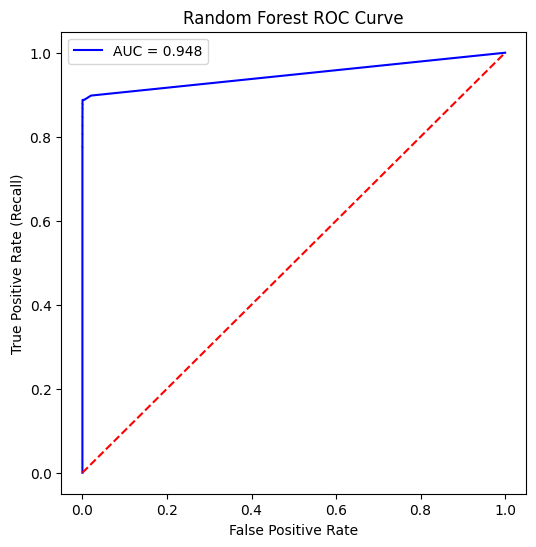

In [36]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

#### 5. Feature Importance:

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', color='green')
plt.title("Top 10 Important Features in Fraud Detection")
plt.show()

#### 6. Hyperparameter Tuning:

In [38]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_


Best parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


### SVM (Support Vector Machine) MODEL:

### 1. Create Model:

In [43]:
svm_model = SVC(
    kernel='rbf',            # 'linear' or 'rbf' (RBF often performs better for complex data)
    C=1.0,                   # regularization strength
    gamma='scale',           # kernel coefficient
    class_weight='balanced', # handle class imbalance
    probability=True,        # enable probability outputs for ROC curve
    random_state=42
)

svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


#### 2. Make Predictions:

In [42]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]  # probabilities for AUC

#### 3. Evaluate the Model:

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.3f}")


#### 4. Plot ROC Curve:

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'SVM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()


#### 5. Hyperparameter Tuning:

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train_res, y_train_res)

print("Best parameters:", grid.best_params_)
best_svm = grid.best_estimator_

### GradientBoostingClassifier:

#### 1. Initialize and Train GBM

In [ ]:
gbm_model = GradientBoostingClassifier(
    n_estimators=200,   # number of boosting stages
    learning_rate=0.1,  # shrinkage rate
    max_depth=3,        # depth of each tree
    random_state=42
)

gbm_model.fit(X_train_res, y_train_res)


#### Using XGBoost:

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),  # handle imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


#### 2. Make Predictions:

In [ ]:
y_pred = gbm_model.predict(X_test)
y_pred_proba = gbm_model.predict_proba(X_test)[:, 1]  # probabilities for AUC

In [ ]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]


#### 3. Evaluate the Model:

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.3f}")


#### 4. Plot ROC Curve:

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'GBM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('GBM ROC Curve')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('your_dataset.csv')

# Preprocess data (handle missing values and encode categorical variables if needed)
df = df.dropna()  # Or fill missing values
df = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target variable (y)
X = df.drop('target_column', axis=1)  # Replace 'target_column' with the actual column name
y = df['target_column']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))
